This notebook is for seeing the data collected for imitation learning.

In [14]:
import numpy as np

data = np.load(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\episode_0.npz")

Dosya içeriği (5 bileşen): ['action', 'cam_0', 'cam_180', 'depth_0', 'depth_180']


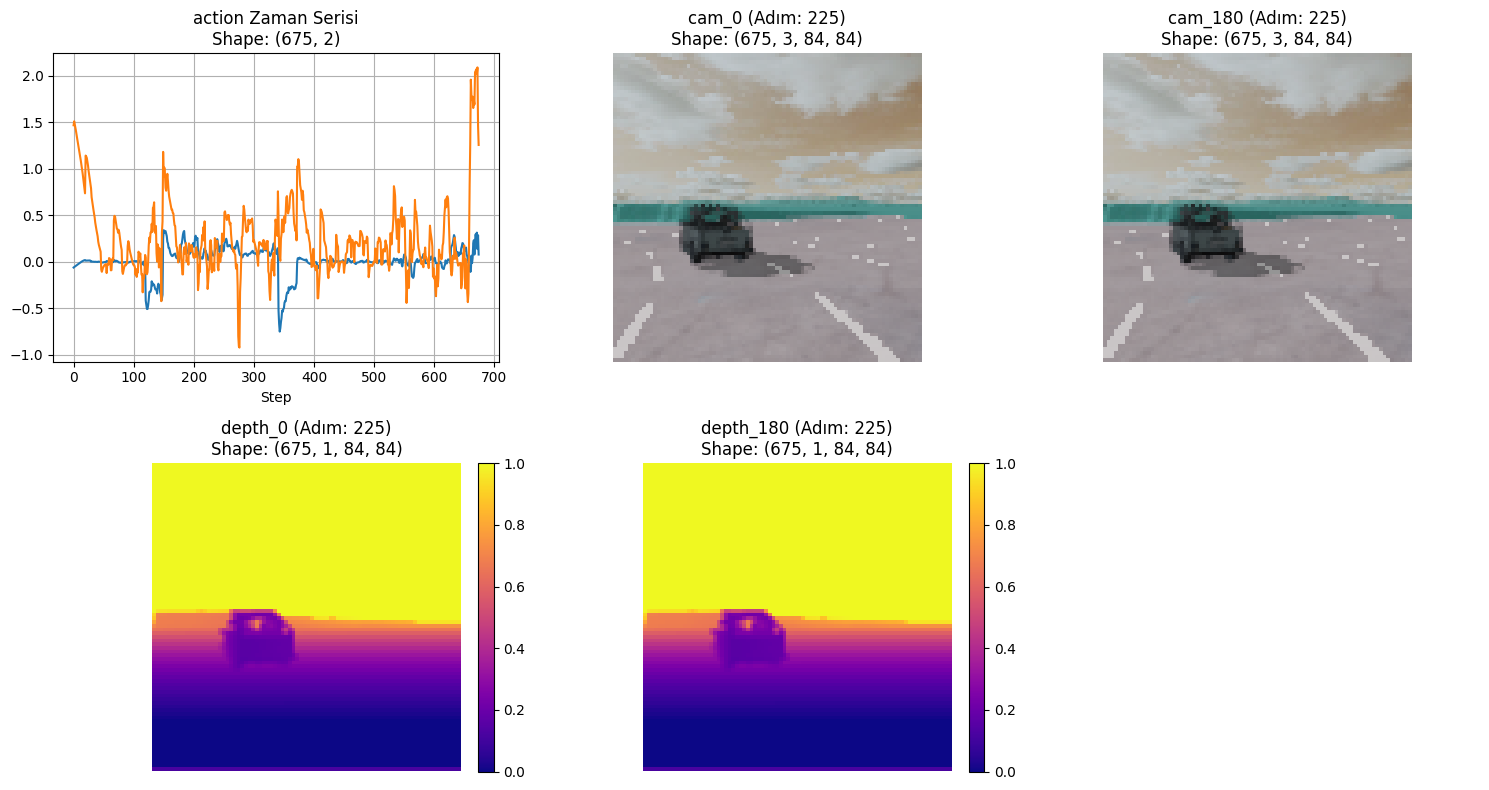

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

def visualize_npz(file_path):
    if not os.path.exists(file_path):
        print(f"Hata: {file_path} bulunamadı.")
        return

    data = np.load(file_path)
    keys = list(data.keys())
    print(f"Dosya içeriği ({len(keys)} bileşen): {keys}")

    n_keys = len(keys)
    
    # --- DİNAMİK IZGARA (GRID) DÜZENİ ---
    # Görüntüleri alt alta dizmek yerine 3 sütunlu bir tablo (grid) oluşturuyoruz
    cols = 3
    rows = math.ceil(n_keys / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    
    # Eksenleri (axes) tek boyutlu bir listeye çeviriyoruz ki döngüde dönmek kolay olsun
    if n_keys == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, key in enumerate(keys):
        arr = data[key]
        ax = axes[i]
        
        # ==========================================
        # 1. GÖRÜNTÜ VERİSİ KONTROLÜ (Kamera/Derinlik)
        # ==========================================
        # Eğer dizi 4 boyutluysa (Step, C, H, W) veya (Step, H, W, C) bunu görüntü kabul et
        if arr.ndim == 4:
            # GÜVENLİK ÖNLEMİ: Bölüm kısa sürdüyse Index hatası almamak için
            # Bölümün tam ortasındaki anı seçiyoruz. İstersen -1 yazarak en son anı da alabilirsin.
            target_step = arr.shape[0] // 3 
            img = arr[target_step]
            
            # Gereksiz 1'lik boyutları at (Örn: 1, 84, 84 -> 84, 84)
            img = np.squeeze(img)
            
            # (C, H, W) -> (H, W, C) dönüşümü (PyTorch formatından Matplotlib formatına)
            if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
                img = img.transpose(1, 2, 0)
                if img.shape[-1] == 1: # Tek kanallı ise tekrar squeeze
                    img = img.squeeze(-1)

            # --- DERİNLİK (DEPTH) İÇİN ÖZEL ---
            if 'depth' in key.lower():
                img_min, img_max = np.min(img), np.max(img)
                if img_max > img_min: 
                    img_normalized = (img - img_min) / (img_max - img_min)
                else:
                    img_normalized = img
                
                im = ax.imshow(img_normalized, cmap='plasma')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04) 
            
            # --- RGB KAMERALAR İÇİN ---
            # 'rgb' adında olmasına gerek yok, 4 boyutluysa ve 'depth' değilse standart resimdir
            else:
                if img.max() > 1.0:
                    img = img.astype(np.uint8)
                ax.imshow(img)
                
            ax.set_title(f"{key} (Adım: {target_step})\nShape: {arr.shape}")
            ax.axis('off')
            
        # ==========================================
        # 2. ZAMAN SERİSİ VERİSİ (Aksiyon, Ödül vb.)
        # ==========================================
        elif arr.ndim <= 2:
            ax.plot(arr)
            ax.set_title(f"{key} Zaman Serisi\nShape: {arr.shape}")
            ax.set_xlabel("Step")
            ax.grid(True)
            
        # Diğer formatlar için hata mesajı
        else:
            ax.text(0.5, 0.5, f"{key}:\nDesteklenmeyen boyut\n{arr.shape}", 
                    ha='center', va='center')
            ax.set_title(key)

    # --- BOŞ KALAN GRAFİK KUTULARINI GİZLEME ---
    # Eğer 13 grafik varsa, 3 sütunlu yapıda 15 kutu oluşur. Son 2 boş kutuyu gizliyoruz.
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Kullanım:
visualize_npz(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\episode_0.npz")

In [3]:
keys = list(data.keys())
print(f"Dosya içeriği: {keys}")

Dosya içeriği: ['rgb', 'depth', 'action']


In [21]:
data.get("action")[0]

array([-0.12874566,  1.3514872 ], dtype=float32)

Initializing model...
[INFO] Base DepthAnythingV2 loaded: C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth
⚠️ Checkpoint not found at Depth-Anything-V2\checkpoints\depth_anything_v2_vits.pth. Using base weights.
Loading frame 50 from c:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\val\episode_80.npz...


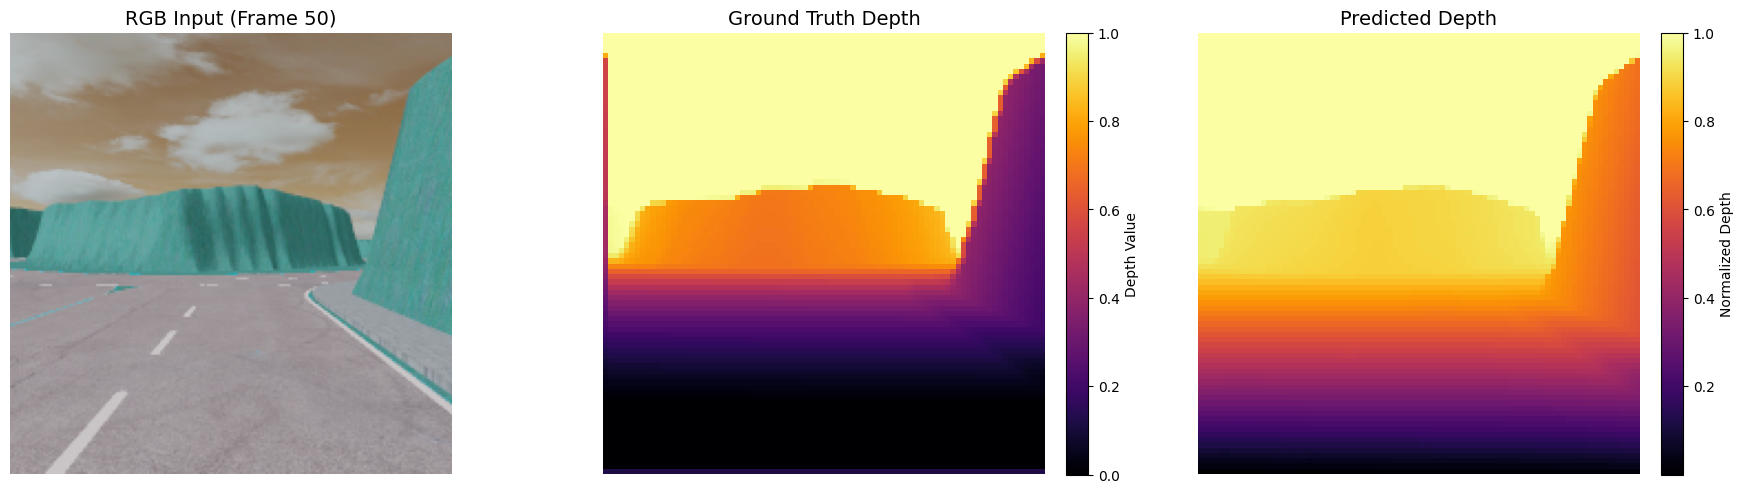

In [3]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# Import your model class from your training script
# (Assuming your script is named train_dpt.py)
import sys

# .parent ile bir üst dizine çıkıyoruz
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.models import DepthEstimationModel

# ==========================================
# 1. SETUP PATHS & PARAMETERS
# ==========================================
model_checkpoint = r"Depth-Anything-V2\checkpoints\depth_anything_v2_vits.pth" # Path to your saved weights
npz_file_path = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")),r"data\raw\val\episode_80.npz") # Path to a specific episode
frame_idx = 50 # Choose which frame in the episode to visualize

# ==========================================
# 2. LOAD MODEL
# ==========================================
print("Initializing model...")
depth_estimator = DepthEstimationModel(encoder='vits', trainable=False)

if os.path.exists(model_checkpoint):
    depth_estimator.model.load_state_dict(torch.load(model_checkpoint, map_location=depth_estimator.device))
    print(f"✅ Loaded fine-tuned weights from {model_checkpoint}")
else:
    print(f"⚠️ Checkpoint not found at {model_checkpoint}. Using base weights.")

# ==========================================
# 3. LOAD DATASET SAMPLE
# ==========================================
print(f"Loading frame {frame_idx} from {npz_file_path}...")
try:
    data = np.load(npz_file_path, allow_pickle=True)
    rgb_keys = [k for k in data.files if k.endswith('_rgb')]
    combined_keys = [k for k in data.files if k.endswith('_combined')]
    
    # Extract the specific frame
    img_rgb = data[rgb_keys[0]][frame_idx]
    
    # Extract GT Depth and format it (drop the channel dimension for plotting)
    # The dataset class uses data[combined_keys[0]][:, 0:1, :, :]
    gt_depth = data[combined_keys[0]][frame_idx, 0, :, :] 
except Exception as e:
    raise ValueError(f"Failed to load data from {npz_file_path}: {e}")

# ==========================================
# 4. RUN INFERENCE
# ==========================================
# Add batch dimension for the model: (H, W, 3) -> (1, H, W, 3)
img_batch = np.expand_dims(img_rgb, axis=0) 

with torch.no_grad():
    pred_depth_tensor = depth_estimator.predict_batch(img_batch)

# Extract prediction: [1, 1, H, W] -> [H, W]
pred_depth = pred_depth_tensor[0, 0].cpu().numpy()

# ==========================================
# 5. VISUALIZE
# ==========================================
# Create a 1x3 grid for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot RGB
axes[0].imshow(img_rgb)
axes[0].set_title(f"RGB Input (Frame {frame_idx})", fontsize=14)
axes[0].axis("off")

# 2. Plot Ground Truth Depth
# Using 'inferno' to easily spot depth differences
im_gt = axes[1].imshow(gt_depth, cmap='inferno')
axes[1].set_title("Ground Truth Depth", fontsize=14)
axes[1].axis("off")
fig.colorbar(im_gt, ax=axes[1], fraction=0.046, pad=0.04, label="Depth Value")

# 3. Plot Predicted Depth
im_pred = axes[2].imshow(pred_depth, cmap='inferno')
axes[2].set_title("Predicted Depth", fontsize=14)
axes[2].axis("off")
fig.colorbar(im_pred, ax=axes[2], fraction=0.046, pad=0.04, label="Normalized Depth")

plt.tight_layout()
plt.show()

[INFO] DepthDataset (train): 43664 samples loaded from C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\train.


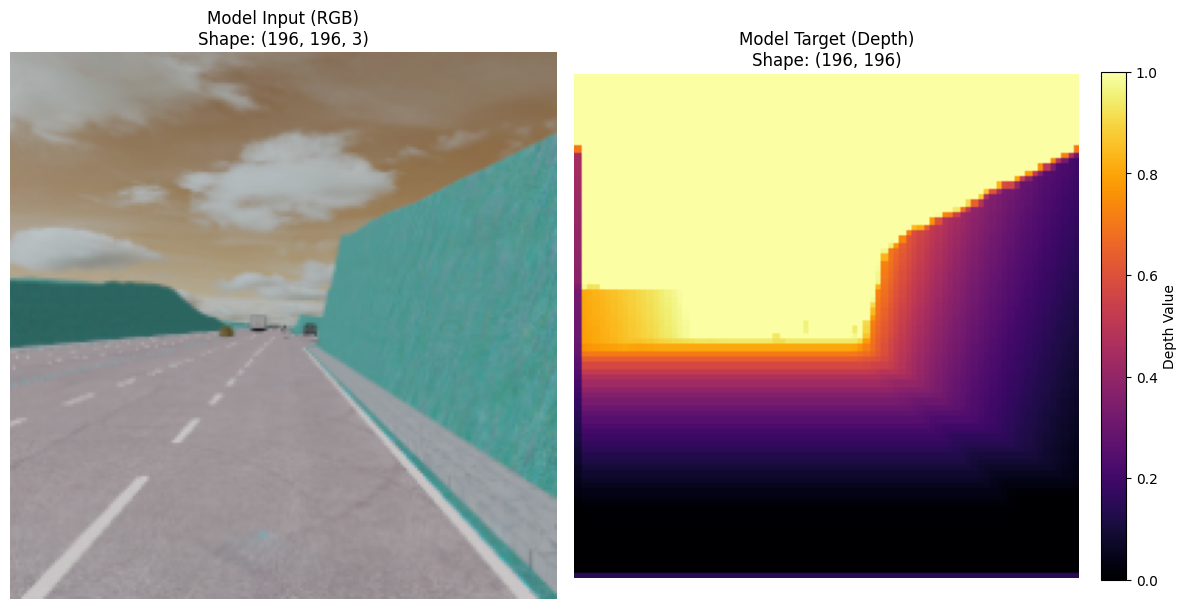

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from src.train_dpt import MetaDriveDepthDataset
# 1. Initialize the dataset exactly as the training loop does
dataset = MetaDriveDepthDataset(
    data_dir=r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw", # Update this path if needed
    split="train", 
    subset_fraction=1.0, 
    augment=True       # Keep True to see the augmentations in action
)

# 2. Grab the first sample
rgb, depth = dataset[0]

# 3. Format RGB for Matplotlib (expects 0-255 uint8 or 0-1 float RGB)
if rgb.max() <= 1.0:
    rgb_disp = (rgb * 255).astype(np.uint8)
else:
    rgb_disp = rgb.astype(np.uint8)

# Format Depth for visualization (squeeze out the channel dimension)
depth_disp = depth.squeeze(0)

# 4. Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_disp)
axes[0].set_title(f"Model Input (RGB)\nShape: {rgb_disp.shape}")
axes[0].axis("off")

# Use inferno colormap to visualize depth intensity
im = axes[1].imshow(depth_disp, cmap="inferno")
axes[1].set_title(f"Model Target (Depth)\nShape: {depth_disp.shape}")
axes[1].axis("off")

# Add a colorbar to see the min/max values of the ground truth
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Depth Value")

plt.tight_layout()
plt.show()

In [41]:
import numpy as np

db = np.load(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\low_aug\test\episode_0.npz")

In [42]:
for i in db.keys():
    print(i)

action
ego_state
ego_state_full
frame_timestamps
cam_0_depth
cam_0_rgb


In [44]:
db.get("cam_0_rgb").shape

(67, 196, 196, 3)

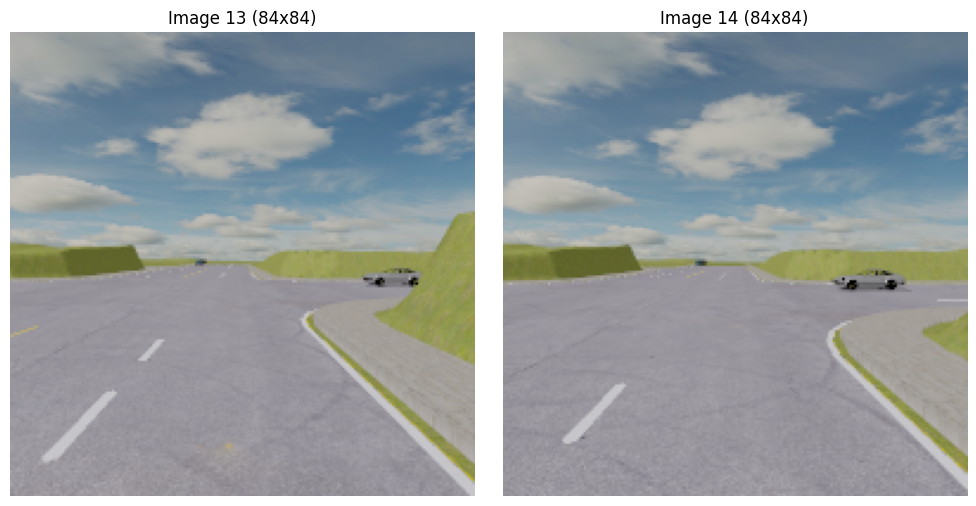

In [49]:
import cv2
import matplotlib.pyplot as plt

# 1. Veriyi al
order = 13
img = db.get("cam_0_rgb")[order]
img2 = db.get("cam_0_rgb")[order+1]

# # 2. Interpolasyon ile 84x84 boyutuna getir
# img = cv2.resize(img, (84, 84), interpolation=cv2.INTER_AREA)
# img2 = cv2.resize(img2, (84, 84), interpolation=cv2.INTER_AREA)

# 3. Görselleştirme (Subplot kullanarak yan yana bastırma)
fig, ax = plt.subplots(1, 2, figsize=(10, 5)) # 1 satır, 2 sütun oluşturur

# Birinci Resim
ax[0].imshow(img)
ax[0].set_title(f"Image {order} (84x84)")
ax[0].axis('off')

# İkinci Resim
ax[1].imshow(img2)
ax[1].set_title(f"Image {order+1} (84x84)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
db.get("rgb").shape

(2500, 196, 196, 3)